# Deep Learning Project


## Installation

In [ ]:
!pip install -q gdown ultralytics albumentations opencv-python


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 11.0 MB/s eta 0:00:00


In [ ]:
#!pip install gdown

# Video of dogs download
!wget "https://box.hu-berlin.de/f/ca45aaedb2074e7ab932/?dl=1" -O dogs_video.mp4

# Manual labels for standing/lying download
!gdown "1PgLyqIpPO9MkpKDuq-XHqn9rII5EceJk" -O direct_video_labels.zip

# Manual labels for all other activities
!gdown "14G72sOs3CWGiYNKSI3o-7k5Kv1wurMWO" -O dog_behavior_labels.zip


# Download dog images from this page http://vision.stanford.edu/aditya86/ImageNetDogs/

--2026-02-24 21:54:14--  https://box.hu-berlin.de/f/ca45aaedb2074e7ab932/?dl=1
Resolving box.hu-berlin.de (box.hu-berlin.de)... 141.20.184.42
Connecting to box.hu-berlin.de (box.hu-berlin.de)|141.20.184.42|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://box.hu-berlin.de/seafhttp/f/ca45aaedb2074e7ab932/ [following]
--2026-02-24 21:54:15--  https://box.hu-berlin.de/seafhttp/f/ca45aaedb2074e7ab932/
Reusing existing connection to box.hu-berlin.de:443.
HTTP request sent, awaiting response... 200 OK
Length: 1646931672 (1.5G) [video/mp4]
Saving to: ‘dogs_video.mp4’

dogs_video.mp4      100%[===================>]   1.53G  7.72MB/s    in 98s     

2026-02-24 21:55:53 (16.1 MB/s) - ‘dogs_video.mp4’ saved [1646931672/1646931672]

Downloading...
From (original): https://drive.google.com/uc?id=1PgLyqIpPO9MkpKDuq-XHqn9rII5EceJk
From (redirected): https://drive.google.com/uc?id=1PgLyqIpPO9MkpKDuq-XHqn9rII5EceJk&confirm=t&uuid=d2e8352b-a686-41a6-8abc-9d8e9d79c4b2

In [ ]:
import zipfile
import os

os.makedirs("dataset/direct_video_labels", exist_ok=True)
os.makedirs("dataset/dog_behavior_labels", exist_ok=True)

with zipfile.ZipFile("direct_video_labels.zip", "r") as z:
    z.extractall("dataset/direct_video_labels")

with zipfile.ZipFile("dog_behavior_labels.zip", "r") as z:
    z.extractall("dataset/dog_behavior_labels")

print("Dataset correctly extracted")


Dataset correctly extracted


In [ ]:
!wget http://vision.stanford.edu/aditya86/ImageNetDogs/images.tar
!tar -xf images.tar


--2026-02-24 21:56:03--  http://vision.stanford.edu/aditya86/ImageNetDogs/images.tar
Resolving vision.stanford.edu (vision.stanford.edu)... 171.64.68.10
Connecting to vision.stanford.edu (vision.stanford.edu)|171.64.68.10|:80... connected.
HTTP request sent, awaiting response... 200 OK
Length: 793579520 (757M) [application/x-tar]
Saving to: ‘images.tar’

images.tar          100%[===================>] 756.82M  7.90MB/s    in 1m 42s  

2026-02-24 21:57:45 (7.41 MB/s) - ‘images.tar’ saved [793579520/793579520]



In [ ]:
import os

print("Video:", os.path.exists("dogs_video.mp4"))
print("Direct labels:", len(os.listdir("dataset/direct_video_labels")))
print("Behavior labels:", len(os.listdir("dataset/dog_behavior_labels")))
print("Dog images folders:", len(os.listdir("Images")))


Video: True
Direct labels: 1
Behavior labels: 1
Dog images folders: 120


In [ ]:
#!pip install ultralytics


## Irrelevant - Augment pictures of dogs for training

In [ ]:
# Removal of directory from previous augmentation run
!rm -rf dog_images_normal/

In [ ]:
import os
import shutil
import glob

src_root = "Images"
dst = "dog_images_normal"
os.makedirs(dst, exist_ok=True)

count = 0
for breed in os.listdir(src_root):
    breed_path = os.path.join(src_root, breed)
    if not os.path.isdir(breed_path):
        continue
    for img in glob.glob(os.path.join(breed_path, "*.jpg")):
        new_name = f"{breed}_{os.path.basename(img)}"
        shutil.copy(img, os.path.join(dst, new_name))
        count += 1

print(f"✅ Copied {count} images into '{dst}'")


✅ Copied 20580 images into 'dog_images_normal'


In [ ]:
import os, glob

print("Exists dog_images_normal:", os.path.exists("dog_images_normal"))
print("Num images in dog_images_normal:", len(glob.glob("dog_images_normal/*")))
print("Exists Images:", os.path.exists("Images"))
print("Num breed folders in Images:", len(os.listdir("Images")) if os.path.exists("Images") else 0)


Exists dog_images_normal: True
Num images in dog_images_normal: 20580
Exists Images: True
Num breed folders in Images: 120


In [ ]:
!rm -rf augmented_images


In [ ]:
import os
import shutil
import zipfile
import glob

# --- CONFIGURATION ---
zip_filename = '/content/dog_behavior_labels.zip'#########'images_shorter.zip'
final_folder = 'dog_images_normal'
temp_folder = 'temp_nuclear_unzip'
# ---------------------

# 1. Verify the zip file exists first
if not os.path.exists(zip_filename):
    print(f"❌ ERROR: Could not find '{zip_filename}' in the current directory.")
    print("Found these zip files instead:")
    print(glob.glob("*.zip"))
    # Stop execution if file missing
    raise FileNotFoundError(f"Please update 'zip_filename' to match one of the files above.")

# 2. Clean setup
if os.path.exists(temp_folder): shutil.rmtree(temp_folder)
os.makedirs(final_folder, exist_ok=True)
os.makedirs(temp_folder, exist_ok=True)

# 3. Unzip
print(f"💥 Extracting '{zip_filename}'...")
with zipfile.ZipFile(zip_filename, 'r') as zip_ref:
    zip_ref.extractall(temp_folder)

# 4. Find and Move EVERYTHING (ignoring extensions)
print(f"Searching for files to flatten into '{final_folder}'...")
moved_count = 0
skipped_junk = 0

for root, dirs, files in os.walk(temp_folder):
    for file in files:
        # Skip Mac/System junk files
        if file.startswith('.') or '__MACOSX' in root or file == '.DS_Store':
            skipped_junk += 1
            continue

        source_path = os.path.join(root, file)
        target_path = os.path.join(final_folder, file)

        # Handle Duplicates (e.g. dog.jpg and subfolder/dog.jpg)
        if os.path.exists(target_path):
            base, ext = os.path.splitext(file)
            counter = 1
            while os.path.exists(os.path.join(final_folder, f"{base}_{counter}{ext}")):
                counter += 1
            target_path = os.path.join(final_folder, f"{base}_{counter}{ext}")

        shutil.move(source_path, target_path)
        moved_count += 1

# 5. Cleanup
shutil.rmtree(temp_folder)
print("-" * 30)
print(f"✅ DONE! Moved {moved_count} files to '{final_folder}'.")
print(f"🗑️ Skipped {skipped_junk} junk files.")

# 6. Verify what we got
if moved_count > 0:
    print(f"First 5 files in {final_folder}:")
    print(os.listdir(final_folder)[:5])
else:
    print("⚠️ Still 0 files? Your zip file might be empty or contain only folders!")

💥 Extracting '/content/dog_behavior_labels.zip'...
Searching for files to flatten into 'dog_images_normal'...
------------------------------
✅ DONE! Moved 273 files to 'dog_images_normal'.
🗑️ Skipped 0 junk files.
First 5 files in dog_images_normal:
['n02110063-malamute_n02110063_8514.jpg', 'n02092002-Scottish_deerhound_n02092002_14102.jpg', 'n02110627-affenpinscher_n02110627_6811.jpg', 'n02091831-Saluki_n02091831_5020.jpg', 'n02097474-Tibetan_terrier_n02097474_5479.jpg']


✅ Folders created. Please upload your dog images to the 'dog_images_normal' folder on the left sidebar.
Found 20722 images. Generating 3 variations for each...


/tmp/ipython-input-1694236513.py:39: UserWarning: Argument(s) 'var_limit' are not valid for transform GaussNoise
  A.GaussNoise(var_limit=(10.0, 50.0), p=0.5),
/tmp/ipython-input-1694236513.py:42: UserWarning: Argument(s) 'quality_lower, quality_upper' are not valid for transform ImageCompression
  A.ImageCompression(quality_lower=10, quality_upper=50, p=0.5),


🎉 Done! Processed images are in 'augmented_images'.


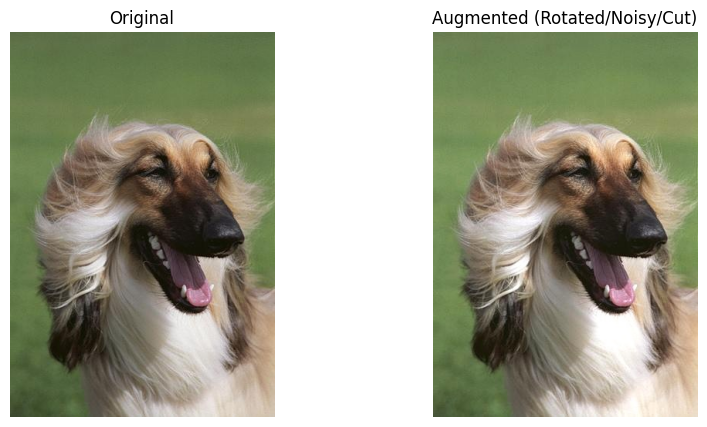

In [ ]:
# 1. Install necessary library
!pip install -q albumentations opencv-python-headless matplotlib

import albumentations as A
import cv2
import os
import glob
import matplotlib.pyplot as plt
from google.colab import files
from PIL import Image

# --- CONFIGURATION ---
INPUT_FOLDER = "dog_images_normal"   # Folder where you upload your dog photos
OUTPUT_FOLDER = "augmented_images" # Folder where results will be saved
NUM_AUGMENTATIONS = 3  # How many new versions to create per original image

# Create folders if they don't exist
os.makedirs(INPUT_FOLDER, exist_ok=True)
os.makedirs(OUTPUT_FOLDER, exist_ok=True)

print(f"✅ Folders created. Please upload your dog images to the '{INPUT_FOLDER}' folder on the left sidebar.")
# You can manually upload files to the folder icon on the left in Colab

# --- THE AUGMENTATION PIPELINE ---
# This defines the "Recipe" for your images
transform = A.Compose([

    # 1. Rotate: Rotates between -30 and +30 degrees
    #A.SafeRotate(limit=30, p=0.7, border_mode=cv2.BORDER_CONSTANT, value=0),

    # 2. Cut part of it (Occlusion): Makes small black holes to simulate objects blocking the dog
    #A.CoarseDropout(
    #    max_holes=8, max_height=32, max_width=32,
    #    min_holes=2, min_height=8, min_width=8,
    #    fill_value=0, p=0.5
    #),

    # 3. Add Noise: Adds grainy noise (Gaussian)
    A.GaussNoise(var_limit=(10.0, 50.0), p=0.5),

    # 4. Less Quality: Simulates low-quality JPEG (compression artifacts)
    A.ImageCompression(quality_lower=10, quality_upper=50, p=0.5),

    # 5. Random Brightness/Contrast (Bonus: helps YOLO generalization)
    A.RandomBrightnessContrast(p=0.4),
])

def run_augmentation():
    # Get all images
    image_paths = glob.glob(os.path.join(INPUT_FOLDER, "*"))
    exts = ('.jpg', '.jpeg', '.png', '.bmp')
    image_paths = [p for p in image_paths if p.lower().endswith(exts)]

    if not image_paths:
        print(f"⚠️ No images found in '{INPUT_FOLDER}'. Upload some first!")
        return

    print(f"Found {len(image_paths)} images. Generating {NUM_AUGMENTATIONS} variations for each...")

    for img_path in image_paths:
        # Read image using OpenCV
        image = cv2.imread(img_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB) # Convert to RGB
        name = os.path.basename(img_path).split('.')[0]

        for i in range(NUM_AUGMENTATIONS):
            # Apply the augmentation pipeline
            augmented = transform(image=image)['image']

            # Save to output folder
            save_name = f"{name}_aug_{i}.jpg"
            save_path = os.path.join(OUTPUT_FOLDER, save_name)

            # Convert back to BGR for saving with OpenCV
            save_img = cv2.cvtColor(augmented, cv2.COLOR_RGB2BGR)
            cv2.imwrite(save_path, save_img)

    print(f"🎉 Done! Processed images are in '{OUTPUT_FOLDER}'.")

    # --- PREVIEW RESULTS ---
    # Show one example to verify
    if image_paths:
        example_out = glob.glob(os.path.join(OUTPUT_FOLDER, f"{name}_aug_0.jpg"))[0]
        plt.figure(figsize=(10, 5))
        plt.subplot(1, 2, 1)
        plt.title("Original")
        plt.imshow(image)
        plt.axis('off')

        plt.subplot(1, 2, 2)
        plt.title("Augmented (Rotated/Noisy/Cut)")
        plt.imshow(Image.open(example_out))
        plt.axis('off')
        plt.show()

# --- RUN IT ---
# Uncomment the line below to run after uploading images
run_augmentation()

In [ ]:
!rm -rf yolo_formatted_dataset

In [ ]:
import os
import random
import shutil

# --- CONFIGURATION ---
source_folder = 'augmented_images'          # Where your current images are
destination_folder = 'random_subset'  # New folder name
extensions = ('.jpg', '.jpeg', '.png') # File types to look for
# ---------------------

# 1. Create destination folder if it doesn't exist
os.makedirs(destination_folder, exist_ok=True)

# 2. Get a list of all image files in the source folder
all_files = [f for f in os.listdir(source_folder) if f.lower().endswith(extensions)]
total_files = len(all_files)

if total_files == 0:
    print(f"No images found in {source_folder}!")
else:
    # 3. Randomly determine HOW MANY images to copy (from 1 to total_files)
    # You can change this to a fixed number if you prefer (e.g., num_to_copy = 100)
    num_to_copy = 200#random.randint(1, total_files)

    # 4. Randomly select specific files based on that number
    selected_files = random.sample(all_files, num_to_copy)

    print(f"Found {total_files} images. Randomly selected {num_to_copy} images to copy.")

    # 5. Copy the files
    for file_name in selected_files:
        src_path = os.path.join(source_folder, file_name)
        dst_path = os.path.join(destination_folder, file_name)
        shutil.copy(src_path, dst_path)

    print(f"Success! {num_to_copy} images copied to '{destination_folder}'.")

Found 62166 images. Randomly selected 200 images to copy.
Success! 200 images copied to 'random_subset'.


In [ ]:
!zip -r -q augmented_images_compressed3.zip random_subset

In [ ]:
!zip -r -q augmented_with_labels.zip /content/dataset_annotated


zip error: Nothing to do! (try: zip -r -q augmented_with_labels.zip . -i /content/dataset_annotated)


## Irrelevant - Automated split of pictures into train/test/val

In [ ]:
!mv images_annotated/imgs/random_subset/* dataset_annotated/images/

mv: cannot stat 'images_annotated/imgs/random_subset/*': No such file or directory


In [ ]:
!mv labels_annotated/anns/* dataset_annotated/labels/

mv: cannot stat 'labels_annotated/anns/*': No such file or directory


In [ ]:
!rm -rf images_annotated

In [ ]:
# 1. Unzip the 'annotated' folder into a folder named 'dataset_annotated'
!unzip -q anns-20260122T210503Z-3-001.zip -d labels_annotated
!unzip -q imgs-20260122T210505Z-3-001.zip -d images_annotated

# 2. The link to the annotations directly from the video
# https://drive.google.com/drive/folders/1O1_OcLiEk83UULFDVVi68iJawiLXvnYb?usp=drive_link


print("✅ Unzipping complete!")

unzip:  cannot find or open anns-20260122T210503Z-3-001.zip, anns-20260122T210503Z-3-001.zip.zip or anns-20260122T210503Z-3-001.zip.ZIP.
unzip:  cannot find or open imgs-20260122T210505Z-3-001.zip, imgs-20260122T210505Z-3-001.zip.zip or imgs-20260122T210505Z-3-001.zip.ZIP.
✅ Unzipping complete!


In [ ]:
#!mkdir dataset_annotated
#!mkdir dataset_annotated/labels
#!mkdir dataset_annotated/images
!mv images_annotated/random_subset/* dataset_annotated/images
!rm -rf images_annotated
!mv labels_annotated/* dataset_annotated/labels
!rm -rf labels_annotated

mv: cannot stat 'images_annotated/random_subset/*': No such file or directory
mv: cannot stat 'labels_annotated/*': No such file or directory


In [ ]:
!rm -rf yolo_formatted_dataset/

In [ ]:
import os
import shutil
import random
import glob

# --- CONFIGURATION ---
raw_folder = 'dataset_annotated'
dataset_name = 'yolo_formatted_dataset'
split_ratio = 0.8
# ---------------------

# 1. Create the YOLO directory structure
for split in ['train', 'val']:
    os.makedirs(f'{dataset_name}/images/{split}', exist_ok=True)
    os.makedirs(f'{dataset_name}/labels/{split}', exist_ok=True)

# 2. Find all images in the 'images' subfolder
images_path = os.path.join(raw_folder, 'images')
image_extensions = ['*.jpg', '*.jpeg', '*.png', '*.JPG']
all_images = []

for ext in image_extensions:
    all_images.extend(glob.glob(os.path.join(images_path, ext)))

print(f"Found {len(all_images)} images in {images_path}")

# 3. Match images with .txt files in the 'labels' subfolder
valid_pairs = []
for img_path in all_images:
    filename = os.path.basename(img_path)
    base_name = os.path.splitext(filename)[0]

    label_path = os.path.join(raw_folder, 'labels', base_name + '.txt')

    if os.path.exists(label_path):
        valid_pairs.append((img_path, label_path))
    else:
        print(f"Warning: No label found for {filename}")

print(f"Found {len(valid_pairs)} valid image-label pairs.")

# 4. Shuffle and Split
random.shuffle(valid_pairs)
split_idx = int(len(valid_pairs) * split_ratio)
train_set = valid_pairs[:split_idx]
val_set = valid_pairs[split_idx:]

# 5. Move files
def move_files(pairs, split):
    print(f"Moving {len(pairs)} files to {split}...")
    for img_src, lbl_src in pairs:
        # Move Image
        shutil.copy(img_src, f'{dataset_name}/images/{split}/{os.path.basename(img_src)}')
        # Move Label
        shutil.copy(lbl_src, f'{dataset_name}/labels/{split}/{os.path.basename(lbl_src)}')

if len(valid_pairs) > 0:
    move_files(train_set, 'train')
    move_files(val_set, 'val')

    # 6. Create data.yaml with UPDATED CLASSES
    # 0 = standing, 1 = lying
    yaml_content = f"""
path: {os.path.abspath(dataset_name)}
train: images/train
val: images/val

nc: 2
names:
  0: standing
  1: lying
"""
    with open(f'{dataset_name}/data.yaml', 'w') as f:
        f.write(yaml_content)

    print("\n✅ Dataset organization complete!")
    print(f"Your ready-to-train data is in: {dataset_name}")
    print("Classes set to: 0: standing, 1: lying")
else:
    print("❌ No valid pairs found. Check if your folder names are exactly 'images' and 'labels'.")

Found 0 images in dataset_annotated/images
Found 0 valid image-label pairs.
❌ No valid pairs found. Check if your folder names are exactly 'images' and 'labels'.


## Actual YOLO Training (pure standing/lying classes)


In [ ]:
!rm -rf direct_video_labels/

In [ ]:
!unzip /content/direct_video_labels.zip -d dataset

Archive:  /content/direct_video_labels.zip
   creating: dataset/direct_video_labels/images/
   creating: dataset/direct_video_labels/images/train/
  inflating: dataset/direct_video_labels/images/train/6frame_0001.jpg  
  inflating: dataset/direct_video_labels/images/train/6frame_0002.jpg  
  inflating: dataset/direct_video_labels/images/train/6frame_0003.jpg  
  inflating: dataset/direct_video_labels/images/train/6frame_0004.jpg  
  inflating: dataset/direct_video_labels/images/train/6frame_0005.jpg  
  inflating: dataset/direct_video_labels/images/train/6frame_0006.jpg  
  inflating: dataset/direct_video_labels/images/train/6frame_0007.jpg  
  inflating: dataset/direct_video_labels/images/train/6frame_0008.jpg  
  inflating: dataset/direct_video_labels/images/train/6frame_0009.jpg  
  inflating: dataset/direct_video_labels/images/train/6frame_0010.jpg  
  inflating: dataset/direct_video_labels/images/train/6frame_0011.jpg  
  inflating: dataset/direct_video_labels/images/train/6frame_

In [ ]:
from ultralytics import YOLO

# 1. Load a fresh model
# model = YOLO('yolov8n.pt')
model = YOLO('yolo11n.pt')

# 2. Train on your newly organized data
model.train(
    data='dataset/direct_video_labels/data.yaml',
    epochs=30,
    imgsz=640,
    project='dog_project',
    name='direct_labels_detect'
)

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.15 🚀 Python-3.12.12 torch-2.10.0+cpu CPU (Intel Xeon CPU @ 2.20GHz)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=dataset/direct_video_labels/data.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7d6dac9c3d40>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.04804

In [ ]:
import cv2
import os
import shutil

video_path = "dogs_video.mp4"
output_dir = "test_frames"
N = 100  # numero di frame totali da estrarre

# reset folder
if os.path.exists(output_dir):
    shutil.rmtree(output_dir)
os.makedirs(output_dir, exist_ok=True)

cap = cv2.VideoCapture(video_path)
total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

# se total non è disponibile, fallback: estrai i primi N*30 frame circa
if total <= 0:
    step = 30
    total = N * step

step = max(total // N, 1)

saved = 0
frame_id = 0

while cap.isOpened() and saved < N:
    ret, frame = cap.read()
    if not ret:
        break

    if frame_id % step == 0:
        out_path = os.path.join(output_dir, f"test_frame_{saved:04d}.jpg")
        cv2.imwrite(out_path, frame)
        saved += 1

    frame_id += 1

cap.release()
print(f"Saved {saved} frames in '{output_dir}' (step={step}, total_frames≈{total})")


Saved 100 frames in 'test_frames' (step=1800, total_frames≈180040)


In [ ]:
!ls test_frames | wc -l



100


In [ ]:
!ls runs/detect


dog_project


In [ ]:
from ultralytics import YOLO
import glob

best_candidates = glob.glob("runs/detect/dog_project/direct_labels_detect*/weights/best.pt")
best_candidates.sort()

assert len(best_candidates) > 0, "❌ Non trovo best.pt in runs/detect/dog_project/..."

best_sl = best_candidates[-1]
print("✅ Using model:", best_sl)

trained_model = YOLO(best_sl)


✅ Using model: runs/detect/dog_project/direct_labels_detect/weights/best.pt


In [ ]:
results = trained_model.predict(
    source="test_frames",
    save=True,
    project="/content/runs",
    name="pred_test_frames"
)



image 1/100 /content/test_frames/test_frame_0000.jpg: 512x640 2 lyings, 235.9ms
image 2/100 /content/test_frames/test_frame_0001.jpg: 512x640 2 lyings, 173.0ms
image 3/100 /content/test_frames/test_frame_0002.jpg: 512x640 1 lying, 187.5ms
image 4/100 /content/test_frames/test_frame_0003.jpg: 512x640 1 standing, 170.5ms
image 5/100 /content/test_frames/test_frame_0004.jpg: 512x640 1 standing, 168.1ms
image 6/100 /content/test_frames/test_frame_0005.jpg: 512x640 1 standing, 166.0ms
image 7/100 /content/test_frames/test_frame_0006.jpg: 512x640 1 standing, 1 lying, 170.2ms
image 8/100 /content/test_frames/test_frame_0007.jpg: 512x640 1 standing, 1 lying, 184.2ms
image 9/100 /content/test_frames/test_frame_0008.jpg: 512x640 1 standing, 1 lying, 166.7ms
image 10/100 /content/test_frames/test_frame_0009.jpg: 512x640 1 lying, 172.0ms
image 11/100 /content/test_frames/test_frame_0010.jpg: 512x640 1 lying, 180.2ms
image 12/100 /content/test_frames/test_frame_0011.jpg: 512x640 1 lying, 190.0ms
i

In [ ]:
# Save trained model
#trained_model = YOLO("/content/runs/detect/dog_project/direct_labels_detect2/weights/best.pt")

# Run prediction on the source directory
#results = model.predict(
    #source="test_frames/test_frames/*",
    #save=True,
    #project="/content/runs"
#)

## YOLO training (other behaviors)

In [ ]:
# Can be tested on the images from the video:
!gdown "1bztGx78VJi5MZ3PqRWDFduth2FVUnhXJ" -O test_frames.zip
!unzip /content/test_frames.zip -d test_frames

Downloading...
From: https://drive.google.com/uc?id=1bztGx78VJi5MZ3PqRWDFduth2FVUnhXJ
To: /content/test_frames.zip
100% 15.5M/15.5M [00:00<00:00, 68.2MB/s]
Archive:  /content/test_frames.zip
   creating: test_frames/test_frames/
  inflating: test_frames/test_frames/frame_0001.jpg  
  inflating: test_frames/test_frames/frame_0002.jpg  
  inflating: test_frames/test_frames/frame_0003.jpg  
  inflating: test_frames/test_frames/frame_0004.jpg  
  inflating: test_frames/test_frames/frame_0005.jpg  
  inflating: test_frames/test_frames/frame_0006.jpg  
  inflating: test_frames/test_frames/frame_0007.jpg  
  inflating: test_frames/test_frames/frame_0008.jpg  
  inflating: test_frames/test_frames/frame_0009.jpg  
  inflating: test_frames/test_frames/frame_0010.jpg  
  inflating: test_frames/test_frames/frame_0011.jpg  
  inflating: test_frames/test_frames/frame_0012.jpg  
  inflating: test_frames/test_frames/frame_0013.jpg  
  inflating: test_frames/test_frames/frame_0014.jpg  
  inflating: te

In [ ]:
!unzip /content/dog_behavior_labels.zip -d behavior
!rm -rf /content/behavior/dog_behavior_annotation/video/

Archive:  /content/dog_behavior_labels.zip
   creating: behavior/dog_behavior_new_annotation/
   creating: behavior/dog_behavior_new_annotation/dog_behavior_annotation/
   creating: behavior/dog_behavior_new_annotation/dog_behavior_annotation/labels/
  inflating: behavior/dog_behavior_new_annotation/dog_behavior_annotation/labels/val.cache  
   creating: behavior/dog_behavior_new_annotation/dog_behavior_annotation/labels/val/
  inflating: behavior/dog_behavior_new_annotation/dog_behavior_annotation/labels/val/inactive-2026-01-27-15h31m27s823 (2).txt  
  inflating: behavior/dog_behavior_new_annotation/dog_behavior_annotation/labels/val/inactive-2026-01-27-15h31m27s823 (3).txt  
  inflating: behavior/dog_behavior_new_annotation/dog_behavior_annotation/labels/val/agonistic-2026-01-27-15h48m05s753 (6).txt  
  inflating: behavior/dog_behavior_new_annotation/dog_behavior_annotation/labels/val/sniffing-2026-01-27-15h37m01s851 (4).txt  
  inflating: behavior/dog_behavior_new_annotation/dog_beh

Remapping all labels to sequential order

In [ ]:
## Not necessary anymore

# import os
# import shutil  # For backup

# base_dir = '/content/behavior/dog_behavior_annotation'
# labels_base = os.path.join(base_dir, 'labels')

# # Backup original labels first
# shutil.make_archive(os.path.join(base_dir, 'labels_backup'), 'zip', labels_base)

# # Define mapping: 15->0, 16->1, etc.
# mapping = {15: 0, 16: 1, 17: 2, 18: 3, 19: 4}

# def remap_labels(labels_dir):
#     for txt_file in os.listdir(labels_dir):
#         if txt_file.endswith('.txt'):
#             path = os.path.join(labels_dir, txt_file)
#             lines = []
#             with open(path, 'r') as f:
#                 for line in f:
#                     parts = line.strip().split()
#                     if parts:
#                         old_id = int(parts[0])
#                         new_id = mapping.get(old_id, old_id)
#                         parts[0] = str(new_id)
#                         lines.append(' '.join(parts))
#             with open(path, 'w') as f:
#                 f.write('\n'.join(lines) + '\n')

# # Remap train and val
# remap_labels(os.path.join(labels_base, 'train'))
# remap_labels(os.path.join(labels_base, 'val'))  # Change to your val path if different

# print("Remapping complete. Delete caches and update data.yaml nc: 5.")

In [ ]:
!mv /content/behavior/dog_behavior_new_annotation/dog_behavior_annotation /content/behavior
!rmdir /content/behavior/dog_behavior_new_annotation

In [ ]:
from ultralytics import YOLO

# 1. Load a fresh model
##########################
# You can play around with different models, for instance "yolo11s.pt" might be better
# on low resoution images
##########################
# model = YOLO('yolov8n.pt')
model = YOLO('yolo11n.pt')

# 2. Train on your newly organized data
##########################
# Usually at least 40 epochs are necessary to gain any tangible results
##########################
model.train(
    data='behavior/dog_behavior_annotation/data.yaml',
    epochs=40,
    imgsz=640,
    project='dog_project',
    name='behavior_labels_detect'
)

New https://pypi.org/project/ultralytics/8.4.16 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.15 🚀 Python-3.12.12 torch-2.10.0+cpu CPU (Intel Xeon CPU @ 2.20GHz)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=behavior/dog_behavior_annotation/data.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=40, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2, 3, 4])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7d6dc06895b0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
        

In [ ]:
# Save trained model
# IMPORTANT: Always adjust the "behavior_labels_detectN" number, might differ based on your current training
# (Usually you want to pick the biggest N that is present in the directory /content/runs/detect/dog_project)
trained_behavior_model = YOLO("/content/runs/detect/dog_project/behavior_labels_detect3/weights/best.pt")

#############################
## Something that can be considered here: if a dog is labeled as sniffing, it is usually also labeled
## as active/inactive depending on its position. It would maybe make sense to have the sniffing label
## take precedence and adjust it so it works here.
## (Maybe it can be done without adjusting the annotations, that would be optimal in my opinion, have a look at it)
#############################
# Run prediction on the source directory
results = model.predict(
    source="test_frames/test_frames/*",
    save=True,
    project="/content/runs"
)

FileNotFoundError: [Errno 2] No such file or directory: '/content/runs/detect/dog_project/behavior_labels_detect3/weights/best.pt'

## Tracking of individual dogs

In [ ]:
import cv2
import numpy as np
import os
from ultralytics import YOLO

# model = YOLO("your_model.pt")  # Uncomment when using the pre-trained model only
frames_dir = "test_frames/test_frames/"
output_dir = "enhanced_tracked_frames/"
os.makedirs(output_dir, exist_ok=True)

for img_name in sorted(os.listdir(frames_dir)):  # Sequential order
    if not img_name.lower().endswith(('.jpg', '.png', '.jpeg')): continue

    frame = cv2.imread(os.path.join(frames_dir, img_name))

    # Denoise
    denoised = cv2.fastNlMeansDenoisingColored(frame, None, 10, 10, 7, 21)

    # Sharpen
    kernel = np.array([[-1,-1,-1], [-1,9,-1], [-1,-1,-1]])
    sharpened = cv2.filter2D(denoised, -1, kernel)

    # CLAHE contrast
    lab = cv2.cvtColor(sharpened, cv2.COLOR_BGR2LAB)
    l, a, b = cv2.split(lab)
    clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8,8))
    cl = clahe.apply(l)
    enhanced = cv2.cvtColor(cv2.merge((cl, a, b)), cv2.COLOR_LAB2BGR)

    # Track
    results = model.track(enhanced, conf=0.01, iou=0.5, persist=True, imgsz=320)
    annotated = results[0].plot() if results[0].boxes else enhanced

    # Save
    cv2.imwrite(os.path.join(output_dir, img_name), annotated)

print("Processing complete. Check", output_dir)


In [ ]:
# First try on tracking dogs
from ultralytics import YOLO

results = model.track(source="enhanced_tracked_frames/*", conf=0.1, iou=0.5, imgsz=320, classes=16, save=True)

### An attempt to create pseudo labels for the dogs

In [ ]:
from ultralytics import YOLO
import os

model = YOLO("yolo11n.pt")  # Custom or yolo11n.pt
results = model.track(
    source="/content/test_frames/test_frames/",
    conf=0.2,  # Low for weak detections
    iou=0.5,
    persist=True,
    save=True,      # Annotated video
    save_txt=True,  # YOLO labels: class x y w h track_id conf frame
    project="pseudo_labels",
    name="video_tracks",
    imgsz=320
)

## Autolabeling of augmented images

In [ ]:
from ultralytics import YOLO
import os
import shutil
import glob
from tqdm.notebook import tqdm

# 1. Load the Teacher Model
# Ensure this path is correct based on your previous training output
teacher_model = YOLO('dog_project/teacher_run/weights/best.pt')

# 2. Define Paths
aug_images_path = 'dataset_augmented'  # Where your unzipped images are
aug_labels_path = 'dataset_augmented/labels'

# Create the specific labels folder if it doesn't exist
os.makedirs(aug_labels_path, exist_ok=True)

# 3. Run Prediction (Auto-labeling)
print("Auto-labeling augmented images...")

# We use project='runs/autolabel' and name='exp' to know EXACTLY where YOLO saves files
# conf=0.5 is safe, but if you get too few labels, try lowering it to 0.25
results = teacher_model.predict(
    source=aug_images_path,
    stream=True,
    save_txt=True,
    conf=0.5,
    project='runs/autolabel',
    name='exp',
    exist_ok=True # Overwrites if exists, so we don't get exp2, exp3...
)

# Trigger the prediction loop
for r in results:
    pass

# 4. MOVE the labels to your dataset folder
# YOLO saves them in: runs/autolabel/exp/labels
generated_labels_dir = 'runs/autolabel/exp/labels'

if os.path.exists(generated_labels_dir):
    txt_files = glob.glob(os.path.join(generated_labels_dir, '*.txt'))

    print(f"Moving {len(txt_files)} labels to {aug_labels_path}...")

    for f in txt_files:
        shutil.move(f, aug_labels_path)

    print(f"✅ Success! Images are in '{aug_images_path}' and labels are in '{aug_labels_path}'.")
else:
    print("⚠️ No labels were generated. Check if your confidence (conf=0.5) is too high or image path is empty.")

In [ ]:
#Merge and train supermodel
import shutil

# 1. Create a final dataset folder
final_dataset = 'final_combined_dataset'
os.makedirs(f'{final_dataset}/images/train', exist_ok=True)
os.makedirs(f'{final_dataset}/labels/train', exist_ok=True)

# 2. Copy the original Annotated data (Assuming Roboflow structure 'train/images')
# Adjust paths if your annotated.zip structure is different
!cp dataset_annotated/train/images/* {final_dataset}/images/train/
!cp dataset_annotated/train/labels/* {final_dataset}/labels/train/

# 3. Copy the Augmented images and their new labels
# Images:
!cp dataset_augmented/* {final_dataset}/images/train/
# Labels (YOLO saves auto-labels in runs/detect/predict/labels):
!cp runs/detect/predict/labels/* {final_dataset}/labels/train/

print("Files merged.")

# 4. Create a new data.yaml for the combined set
yaml_content = f"""
path: {os.path.abspath(final_dataset)}
train: images/train
val: images/train  # We are reusing train for val just for simplicity in this script, strictly you should split them
names:
  0: dog
"""

with open(f'{final_dataset}/data.yaml', 'w') as f:
    f.write(yaml_content)

# 5. FINAL TRAINING
final_model = YOLO('yolov8n.pt')
final_model.train(data=f'{final_dataset}/data.yaml', epochs=50, imgsz=640, project='dog_project', name='final_run')

In [ ]:
# Train for 10 epochs (you can increase this later)
!yolo task=detect mode=train model=yolov8n.pt data=direct_video_labels/data.yaml epochs=10 imgsz=640

In [ ]:
!yolo task=detect mode=predict model=/runs/train/weights/best.pt source=xframes/* save=True

# tracking 2

In [ ]:
!pip install -q ultralytics opencv-python


In [ ]:
# Remove the existing direct_video_labels dataset folder (if it exists)
!rm -rf dataset/direct_video_labels

# Extract the direct_video_labels.zip file into the dataset directory
!unzip -q direct_video_labels.zip -d dataset


In [ ]:
from ultralytics import YOLO

# Load the pretrained YOLO11 nano model
model_sl = YOLO("yolo11n.pt")

# Train the model on the standing/lying dataset
model_sl.train(
    data="dataset/direct_video_labels/data.yaml",  # Dataset configuration file
    epochs=30,                                     # Number of training epochs
    imgsz=640,                                     # Input image size
    batch=8,                                       # Small batch size (CPU-friendly)
    workers=0,                                     # Set to 0 for stability on Windows/Colab
    device="cpu",                                  # Train on CPU
    project="runs",                                # Output project folder
    name="direct_labels_detect"                    # Name of this training run
)

# Path to the best trained weights
best_sl = "runs/detect/direct_labels_detect/weights/best.pt"
print("✅ best standing/lying:", best_sl)


Ultralytics 8.4.12 🚀 Python-3.12.12 torch-2.9.0+cpu CPU (Intel Xeon CPU @ 2.20GHz)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=dataset/direct_video_labels/data.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=direct_labels_detect, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, pati

In [ ]:
import cv2, os, shutil

video_path = "dogs_video.mp4"
out_dir = "test_frames"
N = 100  # Number of frames to extract

# Remove existing output folder (if it exists)
if os.path.exists(out_dir):
    shutil.rmtree(out_dir)

# Create a fresh output directory
os.makedirs(out_dir, exist_ok=True)

# Open the video file
cap = cv2.VideoCapture(video_path)

# Get total number of frames in the video
total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

# Fallback in case frame count is not available
if total <= 0:
    total = N * 1800  # fallback estimate

# Compute step size to uniformly sample N frames
step = max(total // N, 1)

saved, frame_id = 0, 0

# Read video frame by frame
while cap.isOpened() and saved < N:
    ret, frame = cap.read()
    if not ret:
        break

    # Save one frame every "step" frames
    if frame_id % step == 0:
        cv2.imwrite(os.path.join(out_dir, f"test_frame_{saved:04d}.jpg"), frame)
        saved += 1

    frame_id += 1

cap.release()

print(f"✅ Saved {saved} frames in '{out_dir}' (step={step}, total≈{total})")


✅ Saved 100 frames in 'test_frames' (step=1800, total≈180040)


In [ ]:
# Path to the best trained weights for the standing/lying model
best_sl = "/content/runs/detect/runs/direct_labels_detect/weights/best.pt"


In [ ]:
from ultralytics import YOLO

# Load the trained standing/lying model using the best weights
trained_sl = YOLO(best_sl)

# Run inference on the extracted test frames
trained_sl.predict(
    source="test_frames",              # Input folder containing test images
    save=True,                         # Save prediction images with bounding boxes
    project="/content/runs",           # Output base directory
    name="pred_test_frames_sl"         # Name of this prediction run
)

print("✅ saved to /content/runs/detect/pred_test_frames_sl")



image 1/100 /content/test_frames/test_frame_0000.jpg: 512x640 2 lyings, 349.8ms
image 2/100 /content/test_frames/test_frame_0001.jpg: 512x640 2 lyings, 337.3ms
image 3/100 /content/test_frames/test_frame_0002.jpg: 512x640 2 lyings, 336.1ms
image 4/100 /content/test_frames/test_frame_0003.jpg: 512x640 2 standings, 283.4ms
image 5/100 /content/test_frames/test_frame_0004.jpg: 512x640 1 standing, 279.8ms
image 6/100 /content/test_frames/test_frame_0005.jpg: 512x640 2 standings, 313.6ms
image 7/100 /content/test_frames/test_frame_0006.jpg: 512x640 2 standings, 2 lyings, 291.1ms
image 8/100 /content/test_frames/test_frame_0007.jpg: 512x640 2 standings, 1 lying, 701.0ms
image 9/100 /content/test_frames/test_frame_0008.jpg: 512x640 3 standings, 1 lying, 324.1ms
image 10/100 /content/test_frames/test_frame_0009.jpg: 512x640 1 standing, 1 lying, 196.1ms
image 11/100 /content/test_frames/test_frame_0010.jpg: 512x640 2 lyings, 214.6ms
image 12/100 /content/test_frames/test_frame_0011.jpg: 512x64

In [ ]:
# Run multi-object tracking on the test frames using BoT-SORT
trained_sl.track(
    source="test_frames",      # Input folder containing test images
    persist=True,              # Keep consistent track IDs across frames
    conf=0.15,                 # Confidence threshold for detections
    iou=0.6,                   # IoU threshold for NMS
    imgsz=640,                 # Input image size
    tracker="botsort.yaml",    # Tracker configuration file (BoT-SORT)
    save=True,                 # Save annotated tracking images
    save_txt=True,             # Save tracking results as .txt label files
    project="runs",            # Output base directory
    name="track_sl"            # Name of this tracking run
)

print("✅ tracking saved to runs/detect/track_sl")


requirements: Ultralytics requirement ['lap>=0.5.12'] not found, attempting AutoUpdate...
Using Python 3.12.12 environment at: /usr
Resolved 2 packages in 164ms
Prepared 1 package in 29ms
Installed 1 package in 4ms
 + lap==0.5.12

requirements: AutoUpdate success ✅ 0.9s
WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effect


image 1/100 /content/test_frames/test_frame_0000.jpg: 512x640 2 lyings, 178.6ms
image 2/100 /content/test_frames/test_frame_0001.jpg: 512x640 2 lyings, 173.7ms
image 3/100 /content/test_frames/test_frame_0002.jpg: 512x640 2 lyings, 165.4ms
image 4/100 /content/test_frames/test_frame_0003.jpg: 512x640 1 standing, 183.6ms
image 5/100 /content/test_frames/test_frame_0004.jpg: 512x640 1 standing, 172.7ms
image 6/100 /content/test_frames/test_frame_0005.jpg: 512x640 1 standing, 191.4ms
image 7/100 /content/test_frames/test_frame_0006.jpg: 512x640 2 standings, 1 lying, 192.0ms
image 8/100 /content/test_frames/test_frame_0007.jpg: 512x640 1 

In [ ]:
# List the first files inside the track_sl output directory
!ls /content/runs/detect/runs/track_sl | head

# List the first label files generated by the tracker
!ls /content/runs/detect/runs/track_sl/labels | head


labels
test_frame_0000.jpg
test_frame_0001.jpg
test_frame_0002.jpg
test_frame_0003.jpg
test_frame_0004.jpg
test_frame_0005.jpg
test_frame_0006.jpg
test_frame_0007.jpg
test_frame_0008.jpg
test_frame_0000.txt
test_frame_0001.txt
test_frame_0002.txt
test_frame_0003.txt
test_frame_0004.txt
test_frame_0005.txt
test_frame_0006.txt
test_frame_0007.txt
test_frame_0008.txt
test_frame_0009.txt


In [ ]:
!ls /content/runs/detect/runs/track_sl | grep -E "\.jpg$|\.png$" | head -n 10


test_frame_0000.jpg
test_frame_0001.jpg
test_frame_0002.jpg
test_frame_0003.jpg
test_frame_0004.jpg
test_frame_0005.jpg
test_frame_0006.jpg
test_frame_0007.jpg
test_frame_0008.jpg
test_frame_0009.jpg


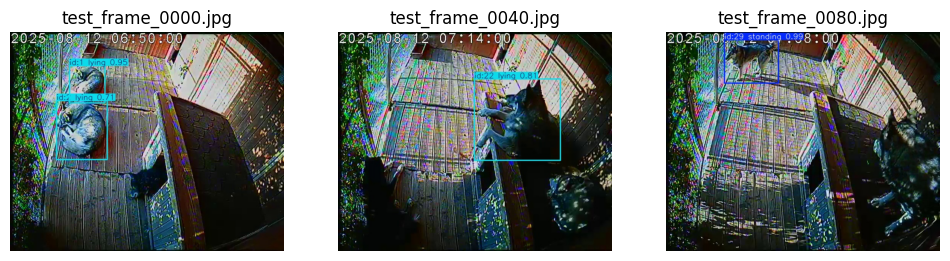

In [ ]:
from PIL import Image
import matplotlib.pyplot as plt

# Paths to selected tracked frames for visualization
img_paths = [
    "/content/runs/detect/runs/track_sl/test_frame_0000.jpg",
    "/content/runs/detect/runs/track_sl/test_frame_0040.jpg",
    "/content/runs/detect/runs/track_sl/test_frame_0080.jpg",
]

# Create a figure to display the images side by side
plt.figure(figsize=(12,4))

for i, p in enumerate(img_paths):
    img = Image.open(p)              # Open image
    plt.subplot(1,3,i+1)             # Create subplot (1 row, 3 columns)
    plt.imshow(img)                  # Display image
    plt.axis("off")                  # Hide axes
    plt.title(p.split("/")[-1])      # Show file name as title

plt.show()  # Render the figure


In [ ]:
import cv2, os, glob

# Directory containing the tracked images
img_dir = "/content/runs/detect/runs/track_sl"

# Output video path
out_video = "/content/runs/detect/runs/track_sl_tracking_demo.mp4"

# Frames per second for the output video
fps = 5

# Collect all .jpg and .png images in sorted order
imgs = sorted(glob.glob(os.path.join(img_dir, "*.jpg")) +
              glob.glob(os.path.join(img_dir, "*.png")))

# Ensure that at least one image is found
assert len(imgs) > 0, "No images found to create the video."

# Read first frame to get video dimensions
frame0 = cv2.imread(imgs[0])
h, w = frame0.shape[:2]

# Define video codec and create VideoWriter object
fourcc = cv2.VideoWriter_fourcc(*"mp4v")
writer = cv2.VideoWriter(out_video, fourcc, fps, (w, h))

# Write each image frame into the video
for p in imgs:
    frame = cv2.imread(p)
    writer.write(frame)

writer.release()

print("✅ Video saved to:", out_video)


✅ Video saved to: /content/runs/detect/runs/track_sl_tracking_demo.mp4


# Tracking 3

In [ ]:
# =========================================================
# MODE B (CPU): Tracking on short clip (30s) - standing/lying
# =========================================================
from ultralytics import YOLO
import glob

# Path to the 0–30 seconds video clip
CLIP_PATH = "/content/clip_0s_30s.mp4"

# Automatically select the latest best.pt weights from training runs
BEST_PT = sorted(glob.glob("/content/runs/detect/dog_project/direct_labels_detect*/weights/best.pt"))[-1]

# Load the trained standing/lying model
model = YOLO(BEST_PT)

# Tracking parameters
CONF = 0.10       # Confidence threshold
IOU = 0.60        # IoU threshold for NMS
IMGSZ = 416       # Input image size (smaller for CPU efficiency)
VID_STRIDE = 1    # Process every frame (increase to skip frames and speed up)

# Run tracking with two different trackers for comparison
for tracker in ["bytetrack.yaml", "botsort.yaml"]:
    run_name = f"track_sl_clip_0s_30s_{tracker.split('.')[0]}"

    model.track(
        source=CLIP_PATH,       # Input video clip
        tracker=tracker,        # Tracker configuration file
        conf=CONF,
        iou=IOU,
        imgsz=IMGSZ,
        persist=True,           # Maintain consistent IDs across frames
        save=True,              # Save annotated video
        save_txt=True,          # Save tracking labels (.txt)
        project="/content/runs",
        name=run_name,
        vid_stride=VID_STRIDE   # Frame sampling stride
    )

    print(f"✅ Created: /content/runs/{run_name}")



WARNING ⚠️ 
Inference results will accumulate in RAM unless `stream=True` is passed, which can cause out-of-memory errors for large
sources or long-running streams and videos. See https://docs.ultralytics.com/modes/predict/ for help.

Example:
    results = model(source=..., stream=True)  # generator of Results objects
    for r in results:
        boxes = r.boxes  # Boxes object for bbox outputs
        masks = r.masks  # Masks object for segment masks outputs
        probs = r.probs  # Class probabilities for classification outputs

video 1/1 (frame 1/1518) /content/clip_0s_30s.mp4: 352x416 1 lying, 78.8ms
video 1/1 (frame 2/1518) /content/clip_0s_30s.mp4: 352x416 1 lying, 75.3ms
video 1/1 (frame 3/1518) /content/clip_0s_30s.mp4: 352x416 1 lying, 74.3ms
video 1/1 (frame 4/1518) /content/clip_0s_30s.mp4: 352x416 1 lying, 75.5ms
video 1/1 (frame 5/1518) /content/clip_0s_30s.mp4: 352x416 1 lying, 81.7ms
video 1/1 (frame 6/1518) /content/clip_0s_30s.mp4: 352x416 1 lying, 82.1ms
video 1/

In [ ]:
from ultralytics import YOLO
import glob, subprocess, os

# Path to the original full video
VIDEO_PATH = "/content/dogs_video.mp4"

# Automatically select the latest best.pt weights from training runs
BEST_PT = sorted(glob.glob("/content/runs/detect/dog_project/direct_labels_detect*/weights/best.pt"))[-1]
print("✅ Using:", BEST_PT)

# ---- Create a short clip (0–30 seconds) from the original video ----
START_SEC = 0
DURATION_SEC = 30
CLIP_PATH = f"/content/clip_{START_SEC}s_{DURATION_SEC}s.mp4"

# Try fast clip extraction without re-encoding
try:
    subprocess.run([
        "ffmpeg", "-y",
        "-ss", str(START_SEC),
        "-i", VIDEO_PATH,
        "-t", str(DURATION_SEC),
        "-c", "copy",
        CLIP_PATH
    ], check=True)

# If it fails, re-encode the video for compatibility
except subprocess.CalledProcessError:
    subprocess.run([
        "ffmpeg", "-y",
        "-ss", str(START_SEC),
        "-i", VIDEO_PATH,
        "-t", str(DURATION_SEC),
        "-c:v", "libx264",
        "-preset", "veryfast",
        "-crf", "23",
        "-c:a", "aac",
        "-b:a", "128k",
        CLIP_PATH
    ], check=True)

# Ensure the clip was successfully created
assert os.path.exists(CLIP_PATH), "❌ Clip not created"
print("✅ Clip:", CLIP_PATH)

# Load the trained standing/lying model
model = YOLO(BEST_PT)

# ---- Run tracking (no stream=True for stability) ----
model.track(
    source=CLIP_PATH,        # Input video clip
    tracker="bytetrack.yaml",
    conf=0.10,               # Confidence threshold
    iou=0.60,                # IoU threshold
    imgsz=416,               # Smaller image size for CPU efficiency
    persist=True,            # Maintain consistent track IDs
    save=True,               # Save annotated output video
    save_txt=True,           # Save tracking labels (.txt)
    project="/content/runs",
    name="DEBUG_TRACK_SL",
    vid_stride=1             # Process every frame
)

print("\n✅ Output created. Folder content:")
!ls -lah /content/runs/detect/DEBUG_TRACK_SL | head -n 50

print("\n✅ Video (if present):")
!find /content/runs/detect/DEBUG_TRACK_SL -maxdepth 2 -type f \( -name "*.mp4" -o -name "*.avi" \)

print("\n✅ Labels (if present):")
!find /content/runs/detect/DEBUG_TRACK_SL -maxdepth 2 -type d -name "labels"


✅ Using: /content/runs/detect/dog_project/direct_labels_detect/weights/best.pt
✅ Clip: /content/clip_0s_30s.mp4

WARNING ⚠️ 
Inference results will accumulate in RAM unless `stream=True` is passed, which can cause out-of-memory errors for large
sources or long-running streams and videos. See https://docs.ultralytics.com/modes/predict/ for help.

Example:
    results = model(source=..., stream=True)  # generator of Results objects
    for r in results:
        boxes = r.boxes  # Boxes object for bbox outputs
        masks = r.masks  # Masks object for segment masks outputs
        probs = r.probs  # Class probabilities for classification outputs

video 1/1 (frame 1/1518) /content/clip_0s_30s.mp4: 352x416 1 lying, 106.4ms
video 1/1 (frame 2/1518) /content/clip_0s_30s.mp4: 352x416 1 lying, 84.6ms
video 1/1 (frame 3/1518) /content/clip_0s_30s.mp4: 352x416 1 lying, 93.4ms
video 1/1 (frame 4/1518) /content/clip_0s_30s.mp4: 352x416 1 lying, 75.2ms
video 1/1 (frame 5/1518) /content/clip_0s_30s

In [ ]:
# =========================================================
# 5-MINUTE TEST (CPU): ByteTrack vs BoT-SORT comparison
# =========================================================

from ultralytics import YOLO
import glob, subprocess, os

# Path to the original full video
VIDEO_PATH = "/content/dogs_video.mp4"
assert os.path.exists(VIDEO_PATH), "❌ Video not found"

# Automatically select the latest best.pt weights from training runs
BEST_PT = sorted(glob.glob("/content/runs/detect/dog_project/direct_labels_detect*/weights/best.pt"))[-1]
print("✅ Best model:", BEST_PT)

# --- Extract a 5-minute clip ---
START_SEC = 0
DURATION_SEC = 300   # 5 minutes
CLIP_PATH = f"/content/clip_{START_SEC}s_{DURATION_SEC}s.mp4"

# Try fast extraction without re-encoding
try:
    subprocess.run(
        ["ffmpeg","-y","-ss",str(START_SEC),"-i",VIDEO_PATH,"-t",str(DURATION_SEC),"-c","copy",CLIP_PATH],
        check=True
    )

# If it fails, re-encode for compatibility
except subprocess.CalledProcessError:
    subprocess.run(
        ["ffmpeg","-y","-ss",str(START_SEC),"-i",VIDEO_PATH,"-t",str(DURATION_SEC),
         "-c:v","libx264","-preset","veryfast","-crf","23","-c:a","aac","-b:a","128k",CLIP_PATH],
        check=True
    )

print("✅ 5-minute clip created:", CLIP_PATH)

# Load the trained standing/lying model
model = YOLO(BEST_PT)

# Tracking parameters
CONF = 0.10
IOU = 0.60
IMGSZ = 416
VID_STRIDE = 5   # Trade-off between CPU speed and tracking quality

# Run tracking with both ByteTrack and BoT-SORT for comparison
for tracker in ["bytetrack.yaml", "botsort.yaml"]:
    run_name = f"track_sl_5min_{tracker.split('.')[0]}"

    model.track(
        source=CLIP_PATH,     # Input video clip
        tracker=tracker,      # Tracker configuration file
        conf=CONF,
        iou=IOU,
        imgsz=IMGSZ,
        persist=True,         # Maintain consistent track IDs
        save=True,            # Save annotated video
        save_txt=True,        # Save tracking label files (.txt)
        project="/content/runs",
        name=run_name,
        vid_stride=VID_STRIDE # Process every N frames
    )

    print(f"✅ Created: /content/runs/{run_name}")


Output streaming troncato alle ultime 5000 righe.
video 1/1 (frame 1015/3000) /content/clip_0s_300s.mp4: 352x416 1 standing, 1 lying, 76.8ms
video 1/1 (frame 1016/3000) /content/clip_0s_300s.mp4: 352x416 1 lying, 78.4ms
video 1/1 (frame 1017/3000) /content/clip_0s_300s.mp4: 352x416 1 lying, 72.9ms
video 1/1 (frame 1018/3000) /content/clip_0s_300s.mp4: 352x416 1 standing, 1 lying, 73.2ms
video 1/1 (frame 1019/3000) /content/clip_0s_300s.mp4: 352x416 (no detections), 77.6ms
video 1/1 (frame 1020/3000) /content/clip_0s_300s.mp4: 352x416 (no detections), 73.1ms
video 1/1 (frame 1021/3000) /content/clip_0s_300s.mp4: 352x416 1 lying, 74.2ms
video 1/1 (frame 1022/3000) /content/clip_0s_300s.mp4: 352x416 1 standing, 78.4ms
video 1/1 (frame 1023/3000) /content/clip_0s_300s.mp4: 352x416 1 standing, 76.6ms
video 1/1 (frame 1024/3000) /content/clip_0s_300s.mp4: 352x416 1 standing, 89.8ms
video 1/1 (frame 1025/3000) /content/clip_0s_300s.mp4: 352x416 1 standing, 73.9ms
video 1/1 (frame 1026/3000) /

In [ ]:
# Modify only the starting point of the 5-minute clip (dogs are static at the beginning)
from ultralytics import YOLO
import glob, subprocess, os

VIDEO_PATH = "/content/dogs_video.mp4"

# Automatically select the latest best.pt weights from training runs
BEST_PT = sorted(glob.glob("/content/runs/detect/dog_project/direct_labels_detect*/weights/best.pt"))[-1]

# Load the trained standing/lying model
model = YOLO(BEST_PT)

# Choose a more "dynamic" section of the video
START_SEC = 1200      # <-- try 600 / 1200 / 1800
DURATION_SEC = 300
CLIP_PATH = f"/content/clip_{START_SEC}s_{DURATION_SEC}s.mp4"

# Try fast extraction without re-encoding
try:
    subprocess.run(
        ["ffmpeg","-y","-ss",str(START_SEC),"-i",VIDEO_PATH,"-t",str(DURATION_SEC),"-c","copy",CLIP_PATH],
        check=True
    )

# If it fails, re-encode for compatibility
except subprocess.CalledProcessError:
    subprocess.run(
        ["ffmpeg","-y","-ss",str(START_SEC),"-i",VIDEO_PATH,"-t",str(DURATION_SEC),
         "-c:v","libx264","-preset","veryfast","-crf","23",
         "-c:a","aac","-b:a","128k",CLIP_PATH],
        check=True
    )

print("✅ Clip created:", CLIP_PATH)

# Tracking parameters (adjusted for more challenging scenes)
CONF = 0.05     # Lower confidence threshold to detect more dogs
IOU = 0.60
IMGSZ = 512     # Higher resolution helps in distant scenes (reduce to 416 if too slow)
VID_STRIDE = 1  # Process every frame for proper tracker evaluation

# Run tracking with ByteTrack and BoT-SORT
for tracker in ["bytetrack.yaml", "botsort.yaml"]:
    run_name = f"track_sl_5min_{START_SEC}s_{tracker.split('.')[0]}_conf{CONF}_img{IMGSZ}"

    model.track(
        source=CLIP_PATH,
        tracker=tracker,
        conf=CONF,
        iou=IOU,
        imgsz=IMGSZ,
        persist=True,         # Maintain consistent track IDs
        save=True,            # Save annotated video
        save_txt=True,        # Save tracking label files (.txt)
        project="/content/runs",
        name=run_name,
        vid_stride=VID_STRIDE
    )

    print("✅ Created:", f"/content/runs/{run_name}")


# Training 3 classes: active (sniffing), inactive, interaction (agonistic and playing) and tracking

In [ ]:
import yaml

yaml_path = "dataset/direct_video_labels/data.yaml"

with open(yaml_path, "r") as f:
    data = yaml.safe_load(f)

print("Numero classi (nc):", data.get("nc"))
print("Nomi classi (ordine → ID):")

for i, name in enumerate(data.get("names", [])):
    print(f"{i}: {name}")


Numero classi (nc): 2
Nomi classi (ordine → ID):
0: standing
1: lying


In [ ]:
# =========================================================
# CPU-SAFE PIPELINE (3 STEP)
# Step 1) Converti dataset 5 classi -> 3 classi (sniffing -> active)
# Step 2) Training YOLO 3 classi (CPU-friendly)
# Step 3) Tracking su CLIP corta (CPU-friendly, video annotato)
# =========================================================

# -------------------------
# REQUISITI (assunti già ok):
# - hai già fatto setup (pip install ultralytics opencv-python)
# - hai già unzip del dataset in: dataset/direct_video_labels
# - hai dogs_video.mp4 nella root
# - data.yaml ha names in ordine: [active, inactive, agonistic, playing, sniffing]
# -------------------------

import os, shutil, glob, subprocess, math
import yaml
from ultralytics import YOLO


# =========================================================
# STEP 0 (consigliato): verifica ordine classi nel data.yaml
# =========================================================
yaml_path = "dataset/direct_video_labels/data.yaml"
assert os.path.exists(yaml_path), f"❌ Non trovo {yaml_path}"

with open(yaml_path, "r") as f:
    data = yaml.safe_load(f)

print("✅ data.yaml letto:", yaml_path)
print("nc:", data.get("nc"))
print("names (ordine -> ID):")
for i, name in enumerate(data.get("names", [])):
    print(f"  {i}: {name}")


# =========================================================
# STEP 1) CONVERSIONE DATASET 5 -> 3
# Nuove classi: [active, inactive, interaction]
# interaction = playing + agonistic
# sniffing -> active
# =========================================================
SRC_DATASET = "dataset/direct_video_labels"
DST_DATASET = "dataset/direct_video_labels_3c"

assert os.path.exists(SRC_DATASET), f"❌ Non trovo {SRC_DATASET}"

if os.path.exists(DST_DATASET):
    shutil.rmtree(DST_DATASET)
shutil.copytree(SRC_DATASET, DST_DATASET)

# mapping basato su ordine: 0 active, 1 inactive, 2 agonistic, 3 playing, 4 sniffing
old_to_new = {
    0: 0,  # active -> active
    1: 1,  # inactive -> inactive
    2: 2,  # agonistic -> interaction
    3: 2,  # playing -> interaction
    4: 0,  # sniffing -> active
}

label_dirs = glob.glob(os.path.join(DST_DATASET, "**", "labels"), recursive=True)
for ld in label_dirs:
    for txt in glob.glob(os.path.join(ld, "*.txt")):
        new_lines = []
        with open(txt, "r") as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) < 5:
                    continue
                cid = int(float(parts[0]))
                if cid not in old_to_new:
                    continue
                parts[0] = str(old_to_new[cid])
                new_lines.append(" ".join(parts))
        with open(txt, "w") as f:
            f.write("\n".join(new_lines) + ("\n" if new_lines else ""))

# aggiorna data.yaml per 3 classi
yaml_dst = os.path.join(DST_DATASET, "data.yaml")
with open(yaml_dst, "r") as f:
    data3 = yaml.safe_load(f)

data3["nc"] = 3
data3["names"] = ["active", "inactive", "interaction"]

with open(yaml_dst, "w") as f:
    yaml.safe_dump(data3, f, sort_keys=False)

print("\n✅ STEP 1 completato")
print("Dataset 3 classi:", DST_DATASET)
print("data.yaml 3 classi:", yaml_dst)
print("names 3c:", data3["names"])


# =========================================================
# STEP 2) TRAINING YOLO (CPU-friendly)
# =========================================================
model_3c = YOLO("yolo11n.pt")

model_3c.train(
    data="dataset/direct_video_labels_3c/data.yaml",
    epochs=25,        # CPU-friendly (aumenta a 35-40 se hai tempo)
    imgsz=416,        # molto più veloce in CPU (512 se vuoi un filo meglio)
    batch=8,          # se va in crash -> 4
    workers=0,
    device="cpu",
    project="runs",
    name="behavior_3c_cpu"
)

best_3c = "runs/detect/behavior_3c_cpu/weights/best.pt"
assert os.path.exists(best_3c), f"❌ Non trovo il best.pt: {best_3c}"
print("\n✅ STEP 2 completato")
print("Best model 3c:", best_3c)


# =========================================================
# STEP 3) TRACKING su CLIP breve (CPU-friendly)
# - crea clip da 30s (modifica START_SEC se vuoi un altro punto)
# - fa tracking con ByteTrack
# =========================================================
VIDEO_PATH = "dogs_video.mp4"
assert os.path.exists(VIDEO_PATH), f"❌ Non trovo {VIDEO_PATH}"

START_SEC = 0
DURATION_SEC = 30
CLIP_PATH = f"clip_{START_SEC}s_{DURATION_SEC}s.mp4"

# crea clip (prova copy veloce; se fallisce, ricodifica)
try:
    subprocess.run(
        ["ffmpeg", "-y", "-ss", str(START_SEC), "-i", VIDEO_PATH, "-t", str(DURATION_SEC), "-c", "copy", CLIP_PATH],
        check=True
    )
except subprocess.CalledProcessError:
    subprocess.run(
        ["ffmpeg", "-y", "-ss", str(START_SEC), "-i", VIDEO_PATH, "-t", str(DURATION_SEC),
         "-c:v", "libx264", "-preset", "veryfast", "-crf", "23",
         "-c:a", "aac", "-b:a", "128k", CLIP_PATH],
        check=True
    )

assert os.path.exists(CLIP_PATH), "❌ Clip non creata"
print("\n✅ Clip creata:", CLIP_PATH)

trained_3c = YOLO(best_3c)

trained_3c.track(
    source=CLIP_PATH,
    tracker="bytetrack.yaml",
    conf=0.10,
    iou=0.6,
    imgsz=416,
    persist=True,
    stream=True,
    save=True,
    save_txt=True,
    project="runs",
    name=f"track_3c_clip_{START_SEC}s_{DURATION_SEC}s_cpu",
    vid_stride=1
)

print("\n✅ STEP 3 completato")
print("Output tracking in:", f"runs/detect/track_3c_clip_{START_SEC}s_{DURATION_SEC}s_cpu")

print("\n--- Video annotati salvati (se presenti) ---")
!find runs/detect -maxdepth 2 -type f \( -name "*.mp4" -o -name "*.avi" \) | sed -n '1,200p'


ModuleNotFoundError: No module named 'ultralytics'